<a href="https://colab.research.google.com/github/ZeninKris/zmm-movilidad-predictiva/blob/main/notebooks/04_EDA_OCISEVI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# ============================================================
# CELDA 1 — Carga y reconocimiento inicial de los 3 RATIV
# Objetivo: entender qué tenemos antes de tocar cualquier dato
# ============================================================

import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

RAW = '/content/drive/MyDrive/Proyecto_ZMM/data_raw/'

# Cargar los 3 archivos
df_23 = pd.read_csv(RAW + 'rativ_abierto_2023.csv', encoding='latin1', low_memory=False)
df_24 = pd.read_csv(RAW + 'rativ_abierto_2024.csv', encoding='latin1', low_memory=False)
df_25 = pd.read_csv(RAW + 'rativ_abierto_2025.csv', encoding='latin1', low_memory=False)

# Vista rápida de cada año
for año, df in [('2023', df_23), ('2024', df_24), ('2025', df_25)]:
    print(f"\n{'='*50}")
    print(f"  RATIV {año} — {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"{'='*50}")
    print(df.dtypes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  RATIV 2023 — 73,107 filas × 121 columnas
MUNICIPIO                          int64
ENCUESTA                           int64
DÃ­a                               int64
Mes                                int64
AÃ±o                               int64
                                   ...  
Fallecido 3                        int64
Dictamen MÃ©dico.2                 int64
Tipo de Ebriedad.2                 int64
Conductor a disposiciÃ³n de .2     int64
ManifestaciÃ³n de los hechos.2    object
Length: 121, dtype: object

  RATIV 2024 — 67,956 filas × 128 columnas
MUNICIPIO                          int64
ENCUESTA                           int64
DÃ­a                               int64
Mes                                int64
AÃ±o                               int64
                                   ...  
Dictamen MÃ©dico.2                 int64
Tipo de Ebriedad.2

In [14]:
# ============================================================
# CELDA 2 — Diagnóstico: encoding, coordenadas y columnas
# ============================================================

# --- 2.1 Corregir encoding de nombres de columna ---
def fix_encoding(df):
    df.columns = [c.encode('latin1').decode('utf-8', errors='replace') for c in df.columns]
    return df

df_23 = fix_encoding(df_23)
df_24 = fix_encoding(df_24)
df_25 = fix_encoding(df_25)

print("✅ Encoding de columnas corregido")
print("\nPrimeras 10 columnas de 2023:")
print(df_23.columns[:10].tolist())

# --- 2.2 Buscar columna de coordenadas ---
print("\n🔍 ¿Existe columna 'Referencia'?")
for año, df in [('2023', df_23), ('2024', df_24), ('2025', df_25)]:
    ref_cols = [c for c in df.columns if 'efer' in c.lower() or 'lat' in c.lower() or 'lon' in c.lower() or 'coord' in c.lower()]
    print(f"  {año}: {ref_cols if ref_cols else '❌ No encontrada'}")

# --- 2.3 Columnas en común vs columnas únicas ---
cols_23 = set(df_23.columns)
cols_24 = set(df_24.columns)
cols_25 = set(df_25.columns)

comunes = cols_23 & cols_24 & cols_25
solo_24 = cols_24 - cols_23 - cols_25
solo_25 = cols_25 - cols_23 - cols_24

print(f"\n📊 Columnas en común (los 3 años): {len(comunes)}")
print(f"   Solo en 2024: {solo_24}")
print(f"   Solo en 2025: {solo_25}")

# --- 2.4 Columnas basura (Unnamed) ---
print("\n🗑️ Columnas basura encontradas:")
for año, df in [('2023', df_23), ('2024', df_24), ('2025', df_25)]:
    basura = [c for c in df.columns if 'Unnamed' in c]
    print(f"  {año}: {basura}")

✅ Encoding de columnas corregido

Primeras 10 columnas de 2023:
['MUNICIPIO', 'ENCUESTA', 'Día', 'Mes', 'Año', 'Día de la semana', 'Hora de reporte', 'Hora de asignación', 'Calle', 'Colonia']

🔍 ¿Existe columna 'Referencia'?
  2023: ['Colonia', 'Referencia']
  2024: ['Colonia', 'Referencia']
  2025: ['Colonia', 'Referencia']

📊 Columnas en común (los 3 años): 119
   Solo en 2024: {'Unnamed: 249', 'Tipo de vialidad'}
   Solo en 2025: {'No de  Infraccion', 'Unnamed: 229', 'Unnamed: 227'}

🗑️ Columnas basura encontradas:
  2023: []
  2024: ['Unnamed: 249']
  2025: ['Unnamed: 227', 'Unnamed: 229']


In [15]:
# ============================================================
# CELDA 3 — ¿Cómo vienen las coordenadas? + limpieza inicial
# ============================================================

# --- 3.1 Ver ejemplos reales de la columna Referencia ---
print("🗺️ Ejemplos de la columna 'Referencia':\n")
for año, df in [('2023', df_23), ('2024', df_24), ('2025', df_25)]:
    muestra = df['Referencia'].dropna().head(5).tolist()
    print(f"  {año}:")
    for v in muestra:
        print(f"    → {v}")
    print()

# --- 3.2 ¿Cuántos siniestros NO tienen coordenadas? ---
print("❓ Nulos en 'Referencia':")
for año, df in [('2023', df_23), ('2024', df_24), ('2025', df_25)]:
    nulos = df['Referencia'].isna().sum()
    pct = nulos / len(df) * 100
    print(f"  {año}: {nulos:,} sin coordenadas ({pct:.1f}%)")

# --- 3.3 Eliminar columnas basura Unnamed ---
basura = ['Unnamed: 249', 'Unnamed: 227', 'Unnamed: 229']
df_24 = df_24.drop(columns=[c for c in basura if c in df_24.columns])
df_25 = df_25.drop(columns=[c for c in basura if c in df_25.columns])

print("\n✅ Columnas basura eliminadas")
print(f"   2024 ahora: {df_24.shape[1]} columnas")
print(f"   2025 ahora: {df_25.shape[1]} columnas")

🗺️ Ejemplos de la columna 'Referencia':

  2023:
    → 99
    → 99
    → 99
    → 99
    → 99

  2024:
    → 25.653085, -100.397545
    → 25.671047, -100.397998
    → 25.686129, -100.416994
    → 25.663848, -100.381837
    → 25.650216, -100.358671

  2025:
    → 25.671176, -100.396215
    → 25.683424, -100.417420
    → 25.647660, -100.332841
    → 25.661059, -100.410031
    → 25.675487, -100.417683

❓ Nulos en 'Referencia':
  2023: 1 sin coordenadas (0.0%)
  2024: 0 sin coordenadas (0.0%)
  2025: 0 sin coordenadas (0.0%)

✅ Columnas basura eliminadas
   2024 ahora: 127 columnas
   2025 ahora: 127 columnas


In [18]:
# ============================================================
# CELDA 4 — Unión de los 3 años en un solo DataFrame
# ============================================================

# --- 4.1 Verificar que el encoding ya está correcto ---
# (fix_encoding se aplicó a df_23/24/25 en Celda 2)
# No re-aplicar aquí — causaría doble encoding y corrompería nombres
print("Columnas de tiempo en df_23 (verificación):")
print([c for c in df_23.columns if c in ['Día', 'Mes', 'Año', 'Día de la semana']])

# --- 4.2 Agregar columna fuente ANTES del concat ---
# Sin tildes ni caracteres especiales — regla para columnas propias
df_23['anio_fuente'] = 2023
df_24['anio_fuente'] = 2024
df_25['anio_fuente'] = 2025

# --- 4.3 Unir los 3 años ---
# join='outer' conserva columnas únicas de cada año como NaN
df = pd.concat([df_23, df_24, df_25], axis=0, ignore_index=True, join='outer')

print(f"\nDataFrame unificado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nDistribucion por año:")
print(df['anio_fuente'].value_counts().sort_index())

# --- 4.4 Vista de columnas clave ---
cols_clave = [
    'MUNICIPIO', 'Día', 'Mes', 'Año', 'Día de la semana',
    'Hora de reporte', 'Calle', 'Colonia', 'Referencia',
    'Tipo de Hecho de Tránsito', 'Condición de clima',
    'Total de lesionados', 'Total de fallecidos', 'Causa del HT'
]

print(f"\nVista de columnas clave:")
print(df[cols_clave].head(3))

Columnas de tiempo en df_23 (verificación):
['Día', 'Mes', 'Año', 'Día de la semana']

DataFrame unificado: 203,890 filas x 131 columnas

Distribucion por año:
anio_fuente
2023    73107
2024    67956
2025    62827
Name: count, dtype: int64

Vista de columnas clave:
   MUNICIPIO  Día  Mes   Año  Día de la semana Hora de reporte  \
0         31    1    1  2023                 1        02:41:00   
1         31    1    1  2023                 1        06:30:00   
2         31    1    1  2023                 1        07:20:00   

                  Calle Colonia Referencia Tipo de Hecho de Tránsito  \
0  ALEJANDRO GARZA LEAL      99         99         Choque de crucero   
1  ARTURO B DE LA GARZA      99         99            Estrellamiento   
2                JAZMIN      99         99            Estrellamiento   

   Condición de clima  Total de lesionados  Total de fallecidos  Causa del HT  
0                   1                    1                    0             3  
1                   

In [19]:
# ============================================================
# CELDA 5 — Calidad de datos: nulos, cardinalidad y tipos
# ============================================================

# --- 5.1 Nulos por columna (solo las que importan) ---
print("📊 Porcentaje de nulos en columnas clave:")
print("-" * 45)

cols_revisar = [
    'MUNICIPIO', 'Día', 'Mes', 'Año', 'Día de la semana',
    'Hora de reporte', 'Calle', 'Colonia', 'Referencia',
    'Tipo de Hecho de Tránsito', 'Condición de clima',
    'VEHICULO CODIFICADO', 'Causa del HT',
    'Total de lesionados', 'Total de fallecidos'
]

nulos = df[cols_revisar].isna().mean() * 100
for col, pct in nulos.sort_values(ascending=False).items():
    estado = "🔴" if pct > 30 else "🟡" if pct > 5 else "🟢"
    print(f"  {estado} {col:<35} {pct:>6.1f}%")

# --- 5.2 Cardinalidad de columnas categóricas clave ---
print("\n📊 Cardinalidad (valores únicos) por columna categórica:")
print("-" * 45)

cols_cat = ['MUNICIPIO', 'Tipo de Hecho de Tránsito',
            'Condición de clima', 'VEHICULO CODIFICADO',
            'Causa del HT', 'Colonia']

for col in cols_cat:
    n = df[col].nunique()
    print(f"  {col:<35} {n:>5} valores únicos")

# --- 5.3 ¿Cuántos siniestros de 2023 tienen calle pero no coordenadas? ---
print("\n🔍 Cobertura de 2023 (sin coordenadas):")
df_23_check = df[df['año_fuente'] == 2023]
tiene_calle  = df_23_check['Calle'].notna() & (df_23_check['Calle'] != '99')
tiene_colonia = df_23_check['Colonia'].notna() & (df_23_check['Colonia'] != '99')

print(f"  Con Calle válida:   {tiene_calle.sum():,} / {len(df_23_check):,} ({tiene_calle.mean()*100:.1f}%)")
print(f"  Con Colonia válida: {tiene_colonia.sum():,} / {len(df_23_check):,} ({tiene_colonia.mean()*100:.1f}%)")

📊 Porcentaje de nulos en columnas clave:
---------------------------------------------
  🟢 Referencia                             0.0%
  🟢 Día                                    0.0%
  🟢 MUNICIPIO                              0.0%
  🟢 Año                                    0.0%
  🟢 Día de la semana                       0.0%
  🟢 Hora de reporte                        0.0%
  🟢 Mes                                    0.0%
  🟢 Calle                                  0.0%
  🟢 Colonia                                0.0%
  🟢 Tipo de Hecho de Tránsito              0.0%
  🟢 Condición de clima                     0.0%
  🟢 VEHICULO CODIFICADO                    0.0%
  🟢 Causa del HT                           0.0%
  🟢 Total de lesionados                    0.0%
  🟢 Total de fallecidos                    0.0%

📊 Cardinalidad (valores únicos) por columna categórica:
---------------------------------------------
  MUNICIPIO                              11 valores únicos
  Tipo de Hecho de Tránsito    

In [20]:
# ============================================================
# CELDA 6 — Nulos reales (códigos 99) y anomalías en catálogos
# ============================================================

# --- 6.1 Los códigos "Sin Dato" según el catálogo OCISEVI ---
# 99 = Sin Dato (numérico), 'SD' y 'NA' también son Sin Dato
CODIGOS_SD = [99, '99', 'SD', 'NA', 'sin dato', 'Sin Dato']

cols_codificadas = [
    'Condición de clima', 'Tipo de Hecho de Tránsito',
    'VEHICULO CODIFICADO', 'Causa del HT',
    'Día de la semana', 'MUNICIPIO'
]

print("📊 Registros con código 'Sin Dato' (99/SD/NA) por columna:")
print("-" * 55)
for col in cols_codificadas:
    n = df[col].isin(CODIGOS_SD).sum()
    pct = n / len(df) * 100
    estado = "🔴" if pct > 10 else "🟡" if pct > 2 else "🟢"
    print(f"  {estado} {col:<35} {n:>7,} ({pct:.1f}%)")

# --- 6.2 Referencia: ¿cuántos son realmente "99"? ---
print("\n🗺️ Referencia — distribución real de valores:")
ref_99   = (df['Referencia'] == '99').sum()
ref_99i  = (df['Referencia'] == 99).sum()
ref_real = df['Referencia'].notna().sum() - ref_99 - ref_99i
print(f"  Con coordenadas reales: {ref_real:,}")
print(f"  Con código 99 (string): {ref_99:,}")
print(f"  Con código 99 (int):    {ref_99i:,}")

# --- 6.3 ¿Qué es ese valor extra en Causa del HT? ---
print("\n🔍 Todos los valores únicos de 'Causa del HT':")
valores = sorted(df['Causa del HT'].dropna().unique().tolist())
print(f"  {valores}")

# --- 6.4 Colonia en 2023: ¿cuántas son '99' vs texto real? ---
df_23_temp = df[df['año_fuente'] == 2023]
col_99 = df_23_temp['Colonia'].isin(CODIGOS_SD).sum()
col_real = len(df_23_temp) - col_99
print(f"\n📍 Colonia en 2023:")
print(f"  Texto real:  {col_real:,} ({col_real/len(df_23_temp)*100:.1f}%)")
print(f"  Código '99': {col_99:,}  ({col_99/len(df_23_temp)*100:.1f}%)")

📊 Registros con código 'Sin Dato' (99/SD/NA) por columna:
-------------------------------------------------------
  🔴 Condición de clima                   24,187 (11.9%)
  🟢 Tipo de Hecho de Tránsito                 0 (0.0%)
  🟢 VEHICULO CODIFICADO                   2,957 (1.5%)
  🟢 Causa del HT                              1 (0.0%)
  🟢 Día de la semana                          0 (0.0%)
  🟢 MUNICIPIO                                 0 (0.0%)

🗺️ Referencia — distribución real de valores:
  Con coordenadas reales: 119,013
  Con código 99 (string): 84,876
  Con código 99 (int):    0

🔍 Todos los valores únicos de 'Causa del HT':
  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 99]

📍 Colonia en 2023:
  Texto real:  35,322 (48.3%)
  Código '99': 37,785  (51.7%)


In [21]:
# ============================================================
# CELDA 7 — Distribución real de coordenadas por año
#           + estrategia para Condición de clima
# ============================================================

# --- 7.1 ¿De qué años vienen los 84,876 sin coordenadas? ---
print("🗺️ Cobertura de coordenadas por año:")
print("-" * 50)

for año in [2023, 2024, 2025]:
    sub = df[df['anio_fuente'] == año]
    sin_coord = (sub['Referencia'] == '99').sum()
    con_coord = len(sub) - sin_coord
    pct_ok = con_coord / len(sub) * 100
    print(f"\n  {año}  ({len(sub):,} siniestros total)")
    print(f"    ✅ Con coordenadas: {con_coord:,}  ({pct_ok:.1f}%)")
    print(f"    ❌ Sin coordenadas: {sin_coord:,}  ({100-pct_ok:.1f}%)")

# --- 7.2 Estrategia para Condición de clima (11.9% sin dato) ---
print("\n\n📊 Condición de clima — distribución completa:")
print("-" * 50)

# Catálogo: 1=Seco, 2=Lluvioso, 3=Granizo, 4=Nieve, 5=Neblina, 6=Hielo, 7=Otro, 99=Sin Dato
catalogo_clima = {
    1: 'Seco', 2: 'Lluvioso', 3: 'Granizo',
    4: 'Nieve', 5: 'Neblina', 6: 'Hielo',
    7: 'Otro', 99: 'Sin Dato'
}

dist_clima = df['Condición de clima'].value_counts().sort_index()
total = len(df)

for codigo, conteo in dist_clima.items():
    nombre = catalogo_clima.get(int(codigo), 'Desconocido')
    pct = conteo / total * 100
    barra = '█' * int(pct / 1)
    print(f"  {codigo:>3} {nombre:<12} {conteo:>7,} ({pct:>5.1f}%) {barra}")

# --- 7.3 ¿Los 99 de clima se concentran en algún año? ---
print("\n📅 Sin Dato en clima por año:")
for año in [2023, 2024, 2025]:
    sub = df[df['anio_fuente'] == año]
    sd = (sub['Condición de clima'] == 99).sum()
    print(f"  {año}: {sd:,} ({sd/len(sub)*100:.1f}%)")

🗺️ Cobertura de coordenadas por año:
--------------------------------------------------

  2023  (73,107 siniestros total)
    ✅ Con coordenadas: 15,643  (21.4%)
    ❌ Sin coordenadas: 57,464  (78.6%)

  2024  (67,956 siniestros total)
    ✅ Con coordenadas: 67,956  (100.0%)
    ❌ Sin coordenadas: 0  (0.0%)

  2025  (62,827 siniestros total)
    ✅ Con coordenadas: 35,415  (56.4%)
    ❌ Sin coordenadas: 27,412  (43.6%)


📊 Condición de clima — distribución completa:
--------------------------------------------------
    1 Seco         168,251 ( 82.5%) ██████████████████████████████████████████████████████████████████████████████████
    2 Lluvioso      10,906 (  5.3%) █████
    3 Granizo            8 (  0.0%) 
    4 Nieve              1 (  0.0%) 
    5 Neblina           10 (  0.0%) 
    7 Otro             527 (  0.3%) 
   99 Sin Dato      24,187 ( 11.9%) ███████████

📅 Sin Dato en clima por año:
  2023: 9,652 (13.2%)
  2024: 8,206 (12.1%)
  2025: 6,329 (10.1%)


In [25]:
# ============================================================
# CELDA 7.5 — Corregir encoding en valores de columnas de texto
# ============================================================

# Columnas cuyos valores (no nombres) tienen encoding roto
cols_texto = [
    'Tipo de Hecho de Tránsito',
    'Calle', 'Colonia', 'Entre Calles', 'Entre Calles.1',
    'Tipo de calle', 'Condiciones del rodamiento',
    'Iluminación', 'Señalamientos'
]

def fix_valor_encoding(valor):
    """Corrige encoding latin1 mal interpretado en valores de texto."""
    if isinstance(valor, str):
        try:
            return valor.encode('latin1').decode('utf-8')
        except (UnicodeDecodeError, UnicodeEncodeError):
            return valor  # si falla, devuelve el original sin romper
    return valor

for col in cols_texto:
    if col in df.columns:
        df[col] = df[col].apply(fix_valor_encoding)

# Verificar resultado
print("Valores únicos corregidos en 'Tipo de Hecho de Tránsito':")
for v in sorted(df['Tipo de Hecho de Tránsito'].dropna().unique()):
    print(f"  → {v}")

Valores únicos corregidos en 'Tipo de Hecho de Tránsito':
  → Alcance
  → Atropello
  → Caída de persona
  → Choque con móvil de vehículo
  → Choque de crucero
  → Choque de frente
  → Choque lateral
  → Estrellamiento
  → Otro
  → Proyección
  → Salida del camino
  → Volcadura


## Decisiones técnicas — Calidad de datos RATIV

### Coordenadas (columna `Referencia`)
- 2024: 100% cobertura → usar lat/lon directo
- 2025: 56.4% cobertura → usar lat/lon donde existe,
  municipio+calle para el resto
- 2023: 21.4% cobertura → usar municipio+calle como
  aproximación geoespacial
- Estrategia: flag `tiene_coordenadas` por fila.
  El modelo sabrá qué tan precisa es cada observación.

### Condición de clima (11.9% código 99)
- Distribuido uniformemente entre años → problema estructural
  de captura, no error puntual
- Estrategia: imputar con la moda por mes+año
  (enero seco ≠ julio seco en Monterrey)
- Se implementa en Feature Engineering, no aquí

### 2023 sin coordenadas mayoritario (78.6%)
- Conservar para análisis temporal (hora, día, tipo accidente)
- Excluir del análisis espacial preciso
- Usar municipio+calle para agrupación geoespacial aproximada

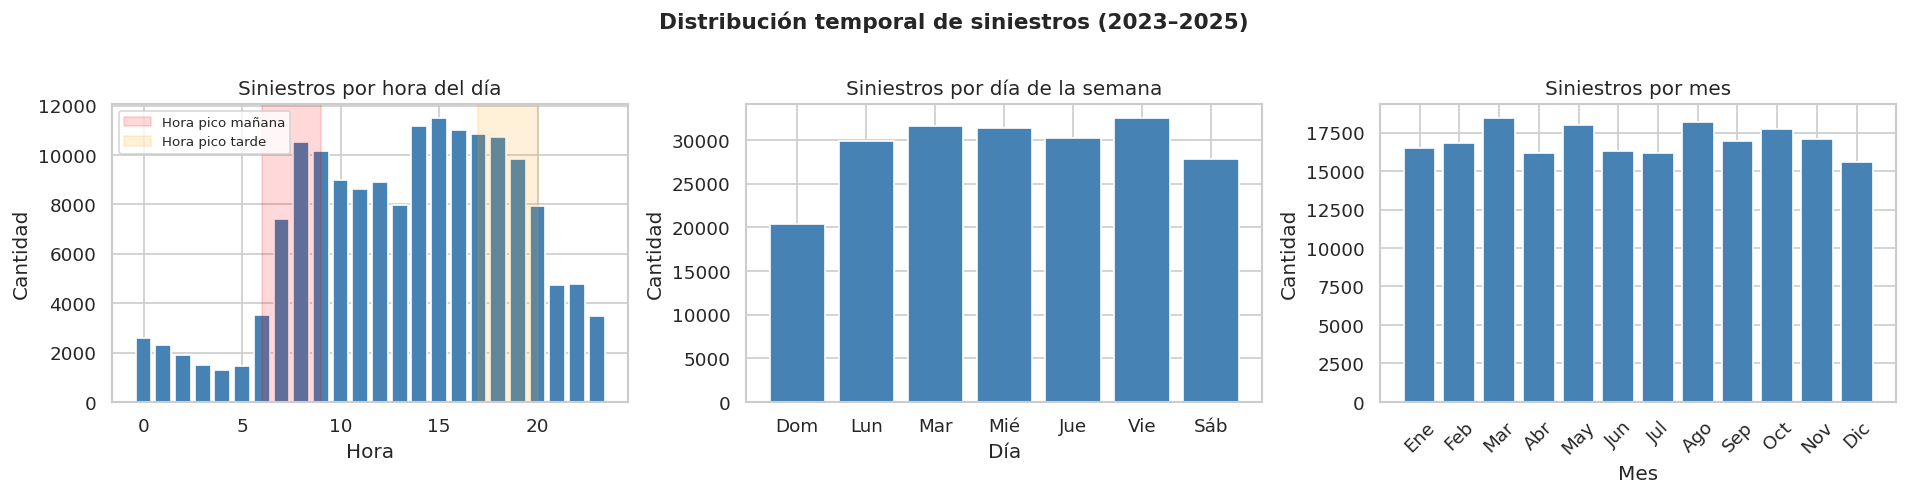

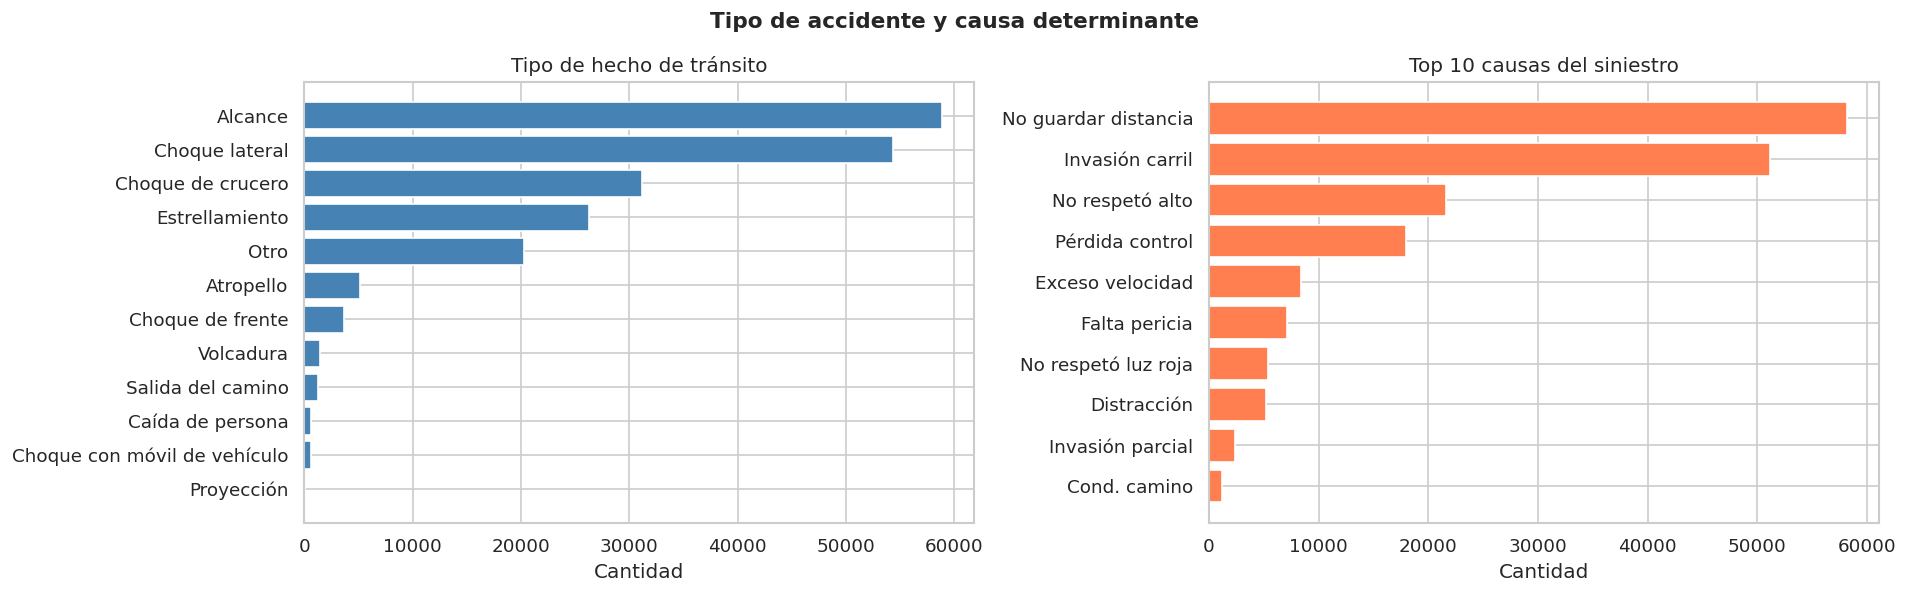

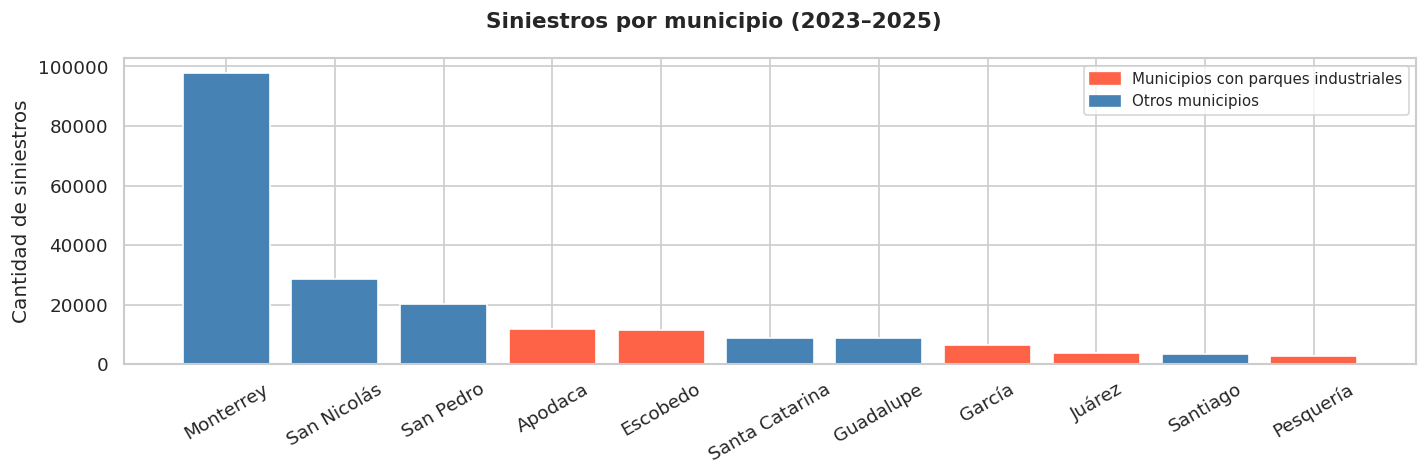

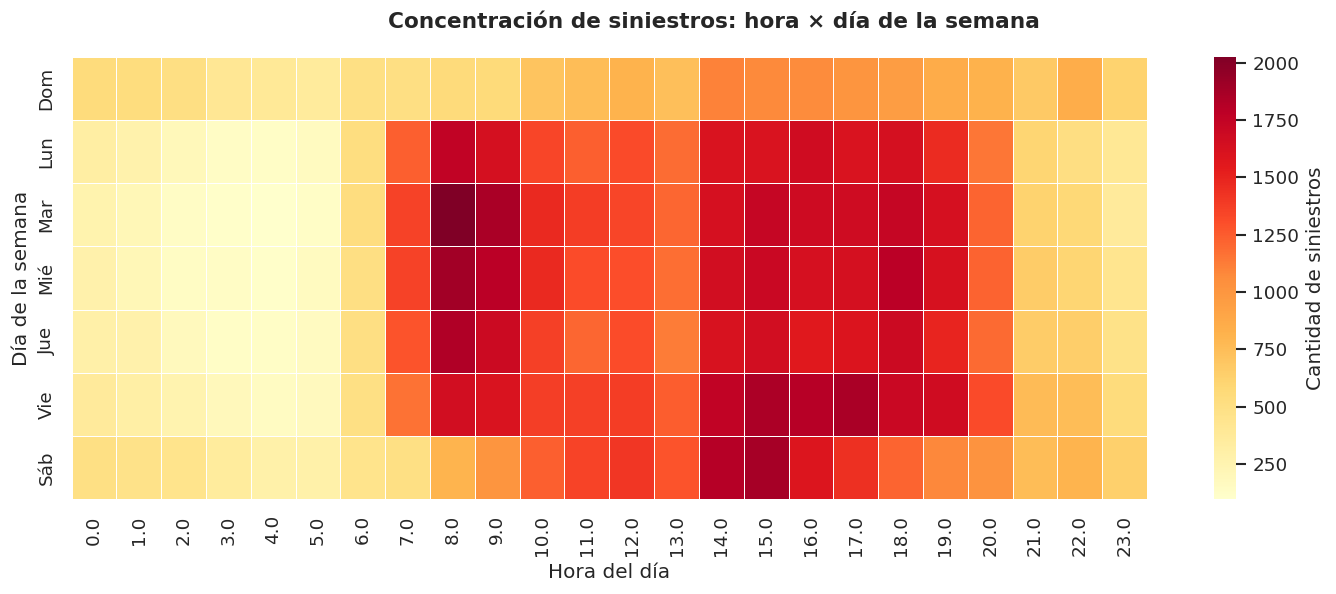

✅ 4 figuras generadas y guardadas


In [26]:
# ============================================================
# CELDA 8 — Visualizaciones EDA
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Estilo general
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Catálogos para etiquetas legibles
CAT_TIPO = {
    1:'Alcance', 2:'Volcadura', 3:'Proyección', 4:'Atropello',
    5:'Choque crucero', 6:'Choque frente', 7:'Choque lateral',
    8:'Choque móvil', 9:'Caída persona', 10:'Salida camino',
    11:'Estrellamiento', 12:'Otro'
}
CAT_CAUSA = {
    1:'No guardar distancia', 2:'Pérdida control', 3:'No respetó alto',
    4:'No respetó luz roja', 5:'Invasión carril', 6:'Invasión parcial',
    7:'Ebriedad', 8:'Falta pericia', 9:'Exceso velocidad',
    10:'Distracción', 11:'Incendio', 12:'Falla vehículo',
    13:'Peatón', 14:'Cond. camino', 15:'Otro'
}
CAT_MUNICIPIO = {
    6:'Apodaca', 18:'García', 19:'San Pedro', 21:'Escobedo',
    26:'Guadalupe', 31:'Juárez', 39:'Monterrey', 41:'Pesquería',
    46:'San Nicolás', 48:'Santa Catarina', 49:'Santiago'
}
CAT_DIA = {
    1:'Dom', 2:'Lun', 3:'Mar', 4:'Mié', 5:'Jue', 6:'Vie', 7:'Sáb'
}

# Preparar datos — excluir Sin Dato donde aplique
df_valido = df[df['Condición de clima'] != 99].copy()
df_tipo   = df[~df['Tipo de Hecho de Tránsito'].isin([99, 12])].copy()
df_causa  = df[~df['Causa del HT'].isin([99, 15])].copy()

# Columna de hora (extraer solo la hora)
df['hora'] = pd.to_datetime(df['Hora de reporte'], format='%H:%M:%S', errors='coerce').dt.hour

# ============================================================
# FIGURA 1 — Distribución temporal
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución temporal de siniestros (2023–2025)',
             fontsize=13, fontweight='bold', y=1.02)

# 1A — Por hora del día
hora_counts = df.groupby('hora').size()
axes[0].bar(hora_counts.index, hora_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Siniestros por hora del día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Cantidad')
axes[0].axvspan(6, 9, alpha=0.15, color='red', label='Hora pico mañana')
axes[0].axvspan(17, 20, alpha=0.15, color='orange', label='Hora pico tarde')
axes[0].legend(fontsize=8)

# 1B — Por día de la semana
dia_counts = df['Día de la semana'].value_counts().sort_index()
dia_labels = [CAT_DIA.get(i, str(i)) for i in dia_counts.index]
axes[1].bar(dia_labels, dia_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Siniestros por día de la semana')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Cantidad')

# 1C — Por mes
mes_counts = df['Mes'].value_counts().sort_index()
meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']
axes[2].bar([meses[i-1] for i in mes_counts.index],
            mes_counts.values, color='steelblue', edgecolor='white')
axes[2].set_title('Siniestros por mes')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('Cantidad')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_01_distribucion_temporal.png', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 2 — Tipo de accidente y causa
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Tipo de accidente y causa determinante',
             fontsize=13, fontweight='bold')

# 2A — Tipo de hecho (ya viene como texto, no código numérico)
tipo_counts = df_tipo['Tipo de Hecho de Tránsito'].value_counts()
axes[0].barh(tipo_counts.index.tolist(), tipo_counts.values,
             color='steelblue', edgecolor='white')
axes[0].set_title('Tipo de hecho de tránsito')
axes[0].set_xlabel('Cantidad')
axes[0].invert_yaxis()

# 2B — Causa del HT (sí viene como código numérico)
causa_counts = df_causa['Causa del HT'].value_counts().head(10)
causa_labels = [CAT_CAUSA.get(int(k), str(k)) for k in causa_counts.index]
axes[1].barh(causa_labels, causa_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Top 10 causas del siniestro')
axes[1].set_xlabel('Cantidad')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_02_tipo_y_causa.png', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 3 — Distribución por municipio
# ============================================================
fig, ax = plt.subplots(figsize=(12, 4))
fig.suptitle('Siniestros por municipio (2023–2025)',
             fontsize=13, fontweight='bold')

mun_counts = df['MUNICIPIO'].value_counts()
mun_labels = [CAT_MUNICIPIO.get(int(k), str(k)) for k in mun_counts.index]

# Resaltar municipios con parques industriales
colores = ['tomato' if CAT_MUNICIPIO.get(int(k)) in
           ['Apodaca', 'Escobedo', 'García', 'Juárez', 'Pesquería']
           else 'steelblue' for k in mun_counts.index]

bars = ax.bar(mun_labels, mun_counts.values, color=colores, edgecolor='white')
ax.set_ylabel('Cantidad de siniestros')
ax.tick_params(axis='x', rotation=30)

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [Patch(color='tomato', label='Municipios con parques industriales'),
           Patch(color='steelblue', label='Otros municipios')]
ax.legend(handles=leyenda, fontsize=9)

plt.tight_layout()
plt.savefig('eda_03_municipios.png', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 4 — Heatmap hora × día de la semana
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Concentración de siniestros: hora × día de la semana',
             fontsize=13, fontweight='bold')

pivot = df.groupby(['Día de la semana', 'hora']).size().unstack(fill_value=0)
pivot.index = [CAT_DIA.get(i, str(i)) for i in pivot.index]

sns.heatmap(pivot, ax=ax, cmap='YlOrRd', fmt='d',
            linewidths=0.3, cbar_kws={'label': 'Cantidad de siniestros'})
ax.set_xlabel('Hora del día')
ax.set_ylabel('Día de la semana')

plt.tight_layout()
plt.savefig('eda_04_heatmap_hora_dia.png', bbox_inches='tight')
plt.show()

print("✅ 4 figuras generadas y guardadas")

## Conclusiones del EDA — RATIV OCISEVI 2023–2025

### Datos
- 203,890 siniestros totales: 73,107 (2023), 67,956 (2024), 62,827 (2025)
- Cobertura de coordenadas heterogénea: 2024 completo (100%),
  2025 parcial (56.4%), 2023 casi sin coordenadas (21.4%)
- 11.9% sin dato en Condición de clima — distribuido uniformemente
  entre años, problema estructural de captura, no error puntual
- Estrategia definida: flag `tiene_coordenadas` por fila;
  imputación de clima por moda mes+año en Feature Engineering

### Distribución temporal
- Dos picos horarios confirmados: 8-9h (entrada turno matutino)
  y 14-15h (salida turno matutino / entrada turno vespertino simultáneos)
  El pico de 14-15h no estaba anticipado en el esqueleto temporal
  y debe incorporarse como hora pico industrial
- Viernes es el día de mayor siniestralidad — patrón documentado
  globalmente asociado a fatiga de fin de semana laboral
- Distribución mensual sin estacionalidad fuerte, con leves alzas
  en marzo, mayo, agosto y octubre
- Limitación técnica identificada: el timestamp registrado es la hora
  de reporte/llegada del oficial, no la hora exacta del accidente.
  Introduce un sesgo sistemático de ~15-45 min en todos los registros.
  Se documenta como limitación del modelo, no se corrige

### Tipo de accidente y causa
- Alcance y choque lateral dominan (~60% combinados)
- Causa principal: no guardar distancia + invasión de carril
- Los tres tipos dominantes son accidentes de tráfico denso,
  no de velocidad — confirma que el problema es congestión,
  no imprudencia aislada. Valida la hipótesis central del proyecto

### Distribución geoespacial
- Monterrey concentra el mayor volumen bruto (~98k siniestros)
  pero tiene ~1.1M habitantes vs ~600k de Apodaca
- Comparación directa de volumen entre municipios es inválida
  sin normalizar por población o flujo vehicular
  (tasa de siniestralidad por 100k habitantes)
- Para este proyecto el municipio es secundario — lo relevante
  es la proximidad geoespacial a parques industriales,
  que se resuelve en Feature Engineering con coordenadas

### Hallazgo del heatmap — dos perfiles de tráfico distintos
- Días laborales (Lun-Vie): concentración clara en 7-9h y 14-19h,
  perfil industrial definido
- Sábado: pico desplazado a 13-15h, consistente con salida
  de medio turno industrial (~1pm)
- Domingo: actividad distribuida en tarde-noche (15-20h),
  perfil recreativo/familiar — conductores, rutas y comportamiento
  completamente distintos al perfil laboral
- Implicación para el modelo: la variable `día de la semana`
  no es suficiente. Se necesita una variable `tipo_dia`
  (laboral_industrial / laboral_mixto / fin_de_semana)
  que capture estos tres perfiles distintos

### Decisiones técnicas tomadas en este EDA
| Decisión | Razonamiento |
|----------|-------------|
| Conservar 2023 sin coordenadas | Válido para análisis temporal; excluir solo del espacial |
| No eliminar filas con clima=99 | 11.9% es demasiado para eliminar; imputar en FE |
| Columnas Unnamed eliminadas | Artefactos de Excel, sin contenido |
| `anio_fuente` sin tilde | Columnas propias nunca llevan caracteres especiales |
| Hora registrada ≠ hora real | Documentar como limitación, no corregir sin evidencia |
```

---

## 💾 Momento de commit

Este es el commit más importante hasta ahora — termina el EDA completo con visualizaciones y conclusiones.

Desde Colab: `Archivo → Guardar una copia en GitHub`

Mensaje del commit:
```
feat: 04 EDA OCISEVI completo - visualizaciones, hallazgos temporales y decisiones técnicas